In [1]:
import os
cwd = os.getcwd().split("\\")[:-1]
cwd = "\\".join(cwd)
os.chdir(cwd)
print(cwd)

C:\Users\Local_Admin\projects\h_lacustris


In [2]:
import importlib.resources
import json

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import polars as pl

from scipy.stats import ttest_ind
from xlsxwriter import Workbook

with importlib.resources.open_text("labutils", "plot_template.json") as file:
  style = json.load(file)

#style["layout"]["colorway"] = random.shuffle(style["layout"]["colorway"])
pio.templates["paper"] = go.layout.Template(
    data=style["data"],
    layout=style["layout"],
)
pio.templates.default = "simple_white+paper"

### Load the data
____

In [3]:
# Light condition
file = "data/2_processed/growth_rates.csv"
fits_df = pl.read_csv(file)
fits_df

condition,plate,well,replicate,model,mu,r2
str,str,str,str,str,f64,f64
"""dark""","""PM2""","""D12""","""P2""","""gompertz""",0.606949,0.985116
"""dark""","""PM2""","""D12""","""P2""","""log""",0.31453,0.915467
"""light""","""PM3""","""D6""","""P3""","""gompertz""",1.988969,0.972979
"""light""","""PM3""","""D6""","""P3""","""log""",0.025337,0.840075
"""light""","""PM3""","""B1""","""P2""","""gompertz""",0.188422,0.563285
…,…,…,…,…,…,…
"""light""","""PM1""","""D11""","""P1""","""log""",0.185288,0.670662
"""light""","""PM1""","""F10""","""P3""","""gompertz""",0.251164,0.960663
"""light""","""PM1""","""F10""","""P3""","""log""",0.150992,0.927361


### Get growth decision
___

#### Higher than control

In [4]:
gpb = fits_df.group_by("condition", "plate", "replicate", "model")
df_to_concat = []
# Growth is positive if the growth rate is higher than the control (well A1)
for name, data in gpb:
    data_tf = data.sort("well").with_columns(
        mu_ref = pl.col("mu").first(),
    ).with_columns(
        growth = pl.col("mu").is_finite() & (pl.col("mu") > pl.col("mu_ref")),
    )
    df_to_concat.append(data_tf)
fits_df = pl.concat(df_to_concat)
fits_df

condition,plate,well,replicate,model,mu,r2,mu_ref,growth
str,str,str,str,str,f64,f64,f64,bool
"""light""","""PM2""","""A1""","""P1""","""log""",0.120166,0.810274,0.120166,false
"""light""","""PM2""","""A10""","""P1""","""log""",0.374948,0.975111,0.120166,true
"""light""","""PM2""","""A11""","""P1""","""log""",0.120017,0.932791,0.120166,false
"""light""","""PM2""","""A12""","""P1""","""log""",0.178095,0.868999,0.120166,true
"""light""","""PM2""","""A2""","""P1""","""log""",0.102979,0.936384,0.120166,false
…,…,…,…,…,…,…,…,…
"""light""","""PM2""","""H5""","""P4""","""gompertz""",0.184357,0.975453,0.185513,false
"""light""","""PM2""","""H6""","""P4""","""gompertz""",1.242638,1.0,0.185513,true
"""light""","""PM2""","""H7""","""P4""","""gompertz""",1.716329,0.90448,0.185513,true


In [5]:
# For a metabolite growth is positive if True in more than thrs replicates
# and if True in both the linear model and the gompertz model
thrs = 2

cols = ["condition", "plate", "well"]
gpb = fits_df.group_by("condition", "plate", "well")
df_to_concat = []
for name, data in gpb:
    growth_dict = {}
    # Growth is positive if mu is higher than the control in at least thrs replicates
    growth_log = sum(data.filter(pl.col("model")=="log")["growth"]) > thrs
    growth_gompertz = sum(data.filter(pl.col("model")=="gompertz")["growth"]) > thrs
    # Decision is positive if True for both the log and gompertz model
    growth_dict["decision"] = all([growth_log, growth_gompertz])
    # Save to new DataFrame
    keys = dict(zip(cols, name))
    keys.update(growth_dict)
    df_to_concat.append(pl.DataFrame(keys))

decision_sum = pl.concat(df_to_concat)
decision_sum = decision_sum.with_columns(
    method = pl.lit("replicates")
)
decision_sum.filter(decision_sum["decision"])

condition,plate,well,decision,method
str,str,str,bool,str
"""light""","""PM1""","""G5""",true,"""replicates"""
"""dark""","""PM2""","""B9""",true,"""replicates"""
"""light""","""PM1""","""F1""",true,"""replicates"""
"""light""","""PM1""","""C5""",true,"""replicates"""
"""light""","""PM2""","""D11""",true,"""replicates"""
…,…,…,…,…
"""light""","""PM1""","""C1""",true,"""replicates"""
"""light""","""PM1""","""B7""",true,"""replicates"""
"""light""","""PM1""","""H10""",true,"""replicates"""


#### Average of Replicates

In [6]:
# Growth decision based on avg of all replicates
# Get the average and std.dv.
fits_avg = fits_df.group_by("condition", "plate", "well", "model").agg(
    pl.col("mu").mean().alias("mu_avg"),
    pl.col("mu").std().alias("mu_std"),
)
gpb = fits_avg.group_by("condition", "plate", "model")
df_to_concat = []
for name, data in gpb:
    # Growth is positive if the growth rate is higher than the control (well A1)
    # Get reference growth rate (mu_ref)
    # test if mu is higher than mu_ref + 1 * sd_ref
    data_tf = data.sort("well").with_columns(
        # Get mu and stddv. of well A1
        m_ref = pl.col("mu_avg").first(),
        m_std_ref = pl.col("mu_std").first()
    ).with_columns(
        # Test positive growth
        growth = pl.col("mu_avg").is_finite() & (pl.col("mu_avg") > (pl.col("m_ref") + pl.col("m_std_ref"))),
    )
    df_to_concat.append(data_tf)
growth_avg = pl.concat(df_to_concat)

cols = ["condition", "plate", "well"]
gpb = growth_avg.group_by("condition", "plate", "well")
df_to_concat = []
for name, data in gpb:
    # Decision is positive if True for both log and gompertz model
    decision_dict = {"decision": all(data["growth"])}
    keys = dict(zip(cols, name))
    keys.update(decision_dict)
    df_to_concat.append(pl.DataFrame(keys))

decision_avg = pl.concat(df_to_concat)
decision_avg = decision_avg.with_columns(
    method = pl.lit("average")
)
decision_avg.filter(decision_avg["decision"])

condition,plate,well,decision,method
str,str,str,bool,str
"""dark""","""PM3""","""D6""",true,"""average"""
"""dark""","""PM3""","""D7""",true,"""average"""
"""light""","""PM2""","""H1""",true,"""average"""
"""dark""","""PM3""","""F12""",true,"""average"""
"""light""","""PM2""","""A5""",true,"""average"""
…,…,…,…,…
"""dark""","""PM3""","""C3""",true,"""average"""
"""light""","""PM1""","""H4""",true,"""average"""
"""dark""","""PM3""","""E1""",true,"""average"""


#### Based on p-value and log2 FC

In [7]:
# Growth decision based on p-values and log2fc
p_thr = 0.05
log2_fc_thr = 0.5

gpb = fits_df.group_by("condition", "plate", "model")
df_to_concat = []
for name, data in gpb:
    # Get mu vals for well A1
    mu_ref = data.filter(pl.col("well")=="A1")["mu"].to_numpy()
    gpb_2 = data.group_by("well")
    for well, data_2 in gpb_2:
        # Get mu values for every other well
        mu_test = data_2["mu"].to_numpy()
        # Welch's t-test and get log2(test/ref)
        stat, p = ttest_ind(mu_ref, mu_test, equal_var=False)
        log2_fc = np.log2(np.mean(mu_test) / np.mean(mu_ref))
        # Save the data
        new_dict = {
            "condition": name[0],
            "plate": name[1],
            "well": well,
            "model": name[2],
            "p": p,
            "log10_p": -np.log10(p),
            "log2_fc": log2_fc,
            # growth is True if p-val and log2FC are above the thresholds
            "growth": (p < p_thr) and (log2_fc > log2_fc_thr)
        }
        df_to_concat.append(pl.DataFrame(new_dict))
growth_pval = pl.concat(df_to_concat)

# Decision
cols = ["condition", "plate", "well"]
gpb = growth_pval.group_by("condition", "plate", "well")
df_to_concat = []
for name, data in gpb:
    # Decision is positive if True for both log and gompertz model
    decision_dict = {"decision": all(data["growth"])}
    keys = dict(zip(cols, name))
    keys.update(decision_dict)
    df_to_concat.append(pl.DataFrame(keys))
decision_pval = pl.concat(df_to_concat)
decision_pval = decision_pval.with_columns(
    method = pl.lit("pval_log2fc")
)
decision_pval.filter(decision_pval["decision"])

condition,plate,well,decision,method
str,str,str,bool,str
"""light""","""PM1""","""B6""",true,"""pval_log2fc"""
"""light""","""PM2""","""A10""",true,"""pval_log2fc"""
"""light""","""PM1""","""C12""",true,"""pval_log2fc"""
"""light""","""PM2""","""C4""",true,"""pval_log2fc"""
"""light""","""PM1""","""A3""",true,"""pval_log2fc"""
…,…,…,…,…
"""light""","""PM1""","""H6""",true,"""pval_log2fc"""
"""light""","""PM1""","""E4""",true,"""pval_log2fc"""
"""light""","""PM1""","""F12""",true,"""pval_log2fc"""


#### Based on all methods

In [9]:
# Bring all decision from the different methods together
mixed = pl.concat([decision_sum, decision_avg, decision_pval])
gpb = mixed.group_by("condition", "plate", "well")
cols = ["condition", "plate", "well"]
df_to_concat = []
for name, data in gpb:
    # Decision is True if true in all methods
    decision_dict = {"decision": all(data["decision"])}
    # Save the data
    keys = dict(zip(cols, name))
    keys.update(decision_dict)
    df_to_concat.append(pl.DataFrame(keys))
decision_all = pl.concat(df_to_concat)
decision_all = decision_pval.with_columns(
    method = pl.lit("all")
)
decision_all.filter(decision_all["decision"])

condition,plate,well,decision,method
str,str,str,bool,str
"""light""","""PM1""","""A8""",true,"""all"""
"""light""","""PM2""","""D5""",true,"""all"""
"""light""","""PM1""","""D12""",true,"""all"""
"""light""","""PM1""","""H3""",true,"""all"""
"""light""","""PM2""","""G9""",true,"""all"""
…,…,…,…,…
"""light""","""PM1""","""D3""",true,"""all"""
"""light""","""PM1""","""H4""",true,"""all"""
"""light""","""PM2""","""C4""",true,"""all"""


In [10]:
# Save the results
biolog_map = pl.read_excel("data/external/biolog_map.xlsx")
corrected_od = pl.read_csv("data/2_processed/corrected_od.csv")

mixed = pl.concat([decision_sum, decision_avg, decision_pval, decision_all])
mixed = mixed.sort(["method", "condition", "plate", "well"])

corrected_od = corrected_od.fill_nan(None)
fits_df = fits_df.fill_nan(None)
growth_avg = growth_avg.fill_nan(None)
growth_pval = growth_pval.fill_nan(None)

mixed = mixed.join(biolog_map, on=["plate", "well"], how="left")
fits_df = fits_df.join(biolog_map, on=["plate", "well"], how="left")
growth_avg = growth_avg.join(biolog_map, on=["plate", "well"], how="left")
growth_pval = growth_pval.join(biolog_map, on=["plate", "well"], how="left")

file = "data/2_processed/supplementary_tables.xlsx"
with Workbook(file) as wb:
    corrected_od.write_excel(wb, worksheet="corrected_od")
    fits_df.write_excel(wb, worksheet="fits")
    growth_avg.write_excel(wb, worksheet="average")
    growth_pval.write_excel(wb, worksheet="p_values")
    mixed.write_excel(wb, worksheet="decision")
print(f"Data sved to: {file}")

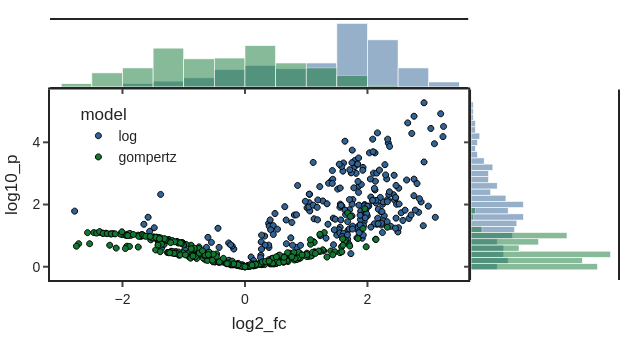

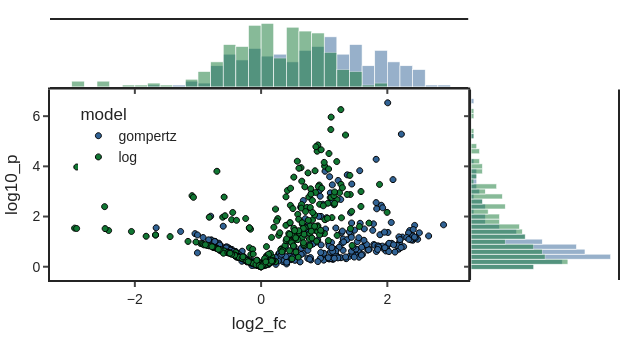

In [17]:
# Dark
fig1 = px.scatter(
    growth_pval.filter(
        pl.col("log2_fc")>-3,
        pl.col("condition")=="dark"
    ),
    x="log2_fc",
    y="log10_p",
    color="model",
    hover_data="well",
    # facet_col="condition",
    marginal_y="histogram",
    marginal_x="histogram"
)
fig1.update_layout({
    "height": 90 * (600 / 158.75),
    "width": 100 * (600 / 158.75),
    "legend": {"x": 0.05, "y":0.7}
})
# Light
fig2 = px.scatter(
    growth_pval.filter(
        pl.col("log2_fc")>-3,
        pl.col("condition")=="light"
    ),
    x="log2_fc",
    y="log10_p",
    color="model",
    hover_data="well",
    # facet_col="condition",
    marginal_y="histogram",
    marginal_x="histogram"
)
fig2.update_layout({
    "height": 90 * (600 / 158.75),
    "width": 100 * (600 / 158.75),
    "legend": {"x": 0.05, "y":0.7}
})
fig1.show()
fig1.write_html("figures/1_volcano_biologs_dark.html")
fig1.write_image("figures/1_volcano_biologs_dark.png")
fig1.write_image("figures/1_volcano_biologs_dark.svg")
fig2.show()
fig2.write_html("figures/1_volcano_biologs_light.html")
fig2.write_image("figures/1_volcano_biologs_light.png")
fig2.write_image("figures/1_volcano_biologs_light.svg")


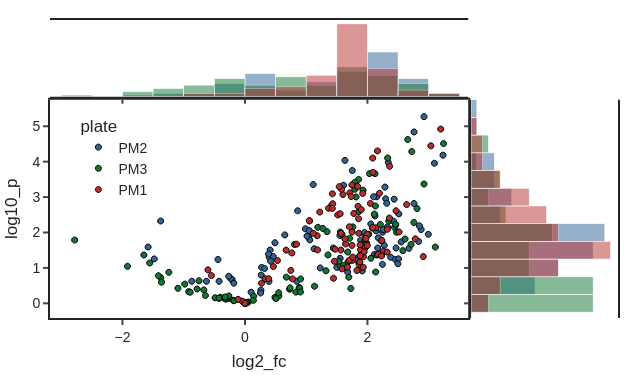

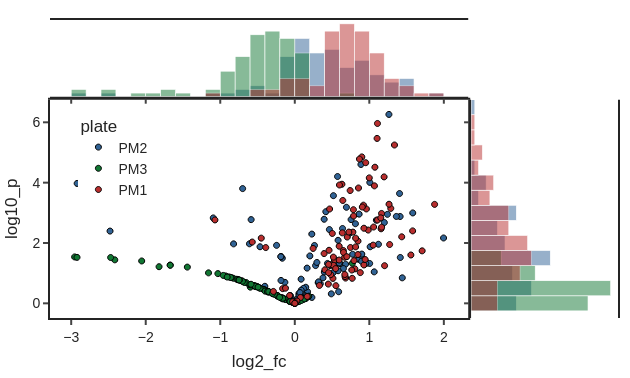

In [13]:
fig1 = px.scatter(
    growth_pval.filter(
        pl.col("log2_fc")>-3,
        pl.col("condition")=="dark",
        pl.col("model")=="log",
    ),
    x="log2_fc",
    y="log10_p",
    color="plate",
    hover_data="well",
    # facet_col="condition",
    marginal_y="histogram",
    marginal_x="histogram"
)
fig1.update_layout({
    "height": 100 * (600 / 158.75),
    "width": 110 * (600 / 158.75),
    "legend": {"x": 0.05, "y":0.7}
})


fig2 = px.scatter(
    growth_pval.filter(
        pl.col("log2_fc")>-3,
        pl.col("condition")=="light",
        pl.col("model")=="log",
    ),
    x="log2_fc",
    y="log10_p",
    color="plate",
    hover_data="well",
    # facet_col="condition",
    marginal_y="histogram",
    marginal_x="histogram"
)
fig2.update_layout({
    "height": 100 * (600 / 158.75),
    "width": 110 * (600 / 158.75),
    "legend": {"x": 0.05, "y":0.7}
})

fig1.show()
fig1.write_html("figures/1_volcano_biologs_dark_log.html")
fig1.write_image("figures/1_volcano_biologs_dark_log.png")
fig1.write_image("figures/1_volcano_biologs_dark_log.svg")
fig2.show()
fig2.write_html("figures/1_volcano_biologs_light_log.html")
fig2.write_image("figures/1_volcano_biologs_light_log.png")
fig2.write_image("figures/1_volcano_biologs_light_log.svg")

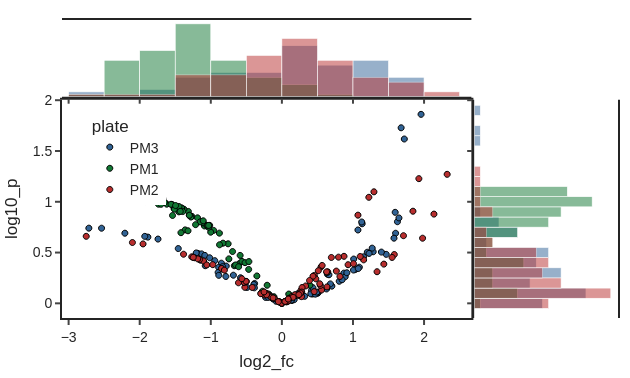

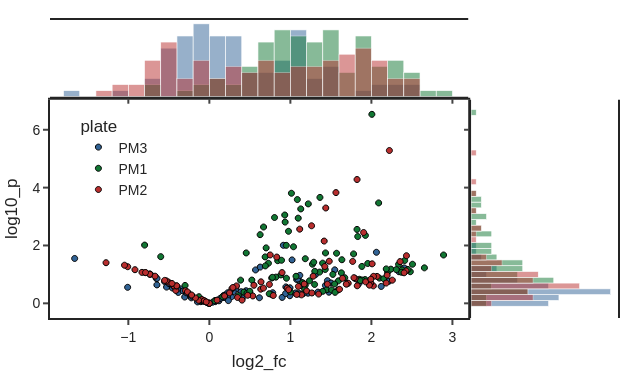

In [14]:
fig1 = px.scatter(
    growth_pval.filter(
        pl.col("log2_fc")>-3,
        pl.col("condition")=="dark",
        pl.col("model")=="gompertz",
    ),
    x="log2_fc",
    y="log10_p",
    color="plate",
    hover_data="well",
    # facet_col="condition",
    marginal_y="histogram",
    marginal_x="histogram"
)
fig1.update_layout({
    "height": 100 * (600 / 158.75),
    "width": 110 * (600 / 158.75),
    "legend": {"x": 0.05, "y":0.7}
})


fig2 = px.scatter(
    growth_pval.filter(
        pl.col("log2_fc")>-3,
        pl.col("condition")=="light",
        pl.col("model")=="gompertz",
    ),
    x="log2_fc",
    y="log10_p",
    color="plate",
    hover_data="well",
    # facet_col="condition",
    marginal_y="histogram",
    marginal_x="histogram"
)
fig2.update_layout({
    "height": 100 * (600 / 158.75),
    "width": 110 * (600 / 158.75),
    "legend": {"x": 0.05, "y":0.7}
})

fig1.show()
fig1.write_html("figures/1_volcano_biologs_dark_gompertz.html")
fig1.write_image("figures/1_volcano_biologs_dark_gompertz.png")
fig1.write_image("figures/1_volcano_biologs_dark_gompertz.svg")
fig2.show()
fig2.write_html("figures/1_volcano_biologs_light_gompertz.html")
fig2.write_image("figures/1_volcano_biologs_light_gompertz.png")
fig2.write_image("figures/1_volcano_biologs_light_gompertz.svg")

#### Growth rate histogram for log model

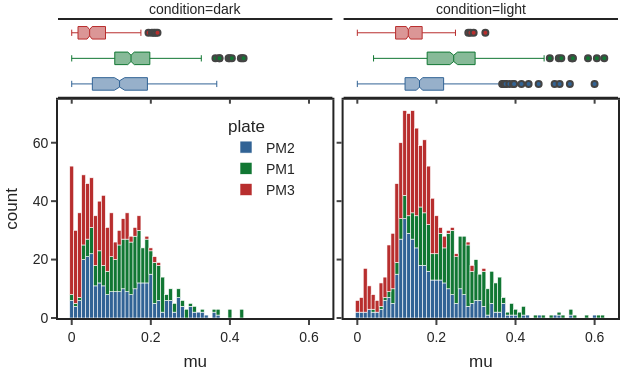

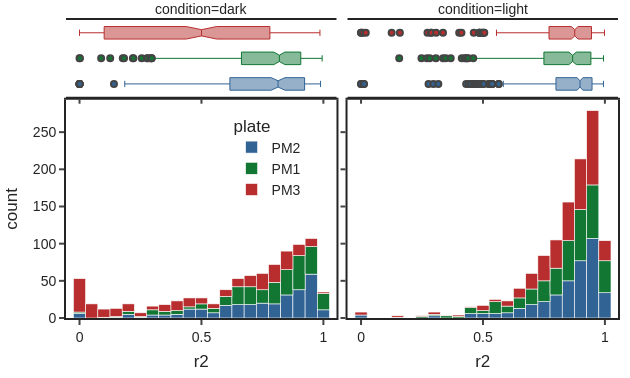

In [9]:
plot_df = fits_df.filter(pl.col("model")=="log").sort("condition")
# Growth rates
fig1 = px.histogram(
    plot_df,
    x="mu",
    facet_col="condition",
    color="plate",
    marginal="box"
)
fig1.update_layout({
    "height": 100 * (600 / 158.75),
    "width": 180 * (600 / 158.75),
    "legend": {"x": 0.3, "y":0.7}
})
# R^2 rates
fig2 = px.histogram(
    plot_df,
    x="r2",
    facet_col="condition",
    color="plate",
    marginal="box"
)
fig2.update_layout({
    "height": 100 * (600 / 158.75),
    "width": 180 * (600 / 158.75),
    "legend": {"x": 0.3, "y":0.7}
})

fig1.show()
fig1.write_html("figures/2_mu_histogram_log.html")
fig1.write_image("figures/2_mu_histogram_log.png")
fig1.write_image("figures/2_mu_histogram_log.svg")
fig2.show()
fig2.write_html("figures/2_r2_histogram_log.html")
fig2.write_image("figures/2_r2_histogram_log.png")
fig2.write_image("figures/2_r2_histogram_log.svg")

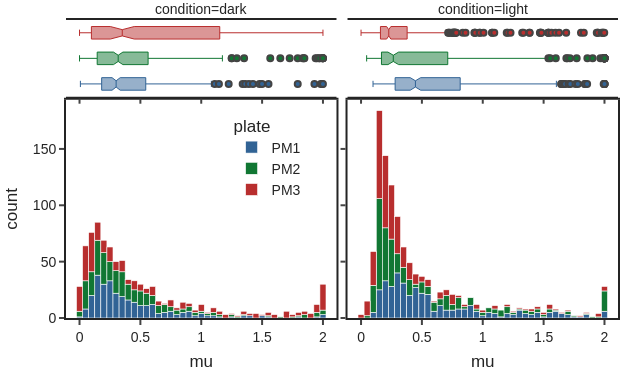

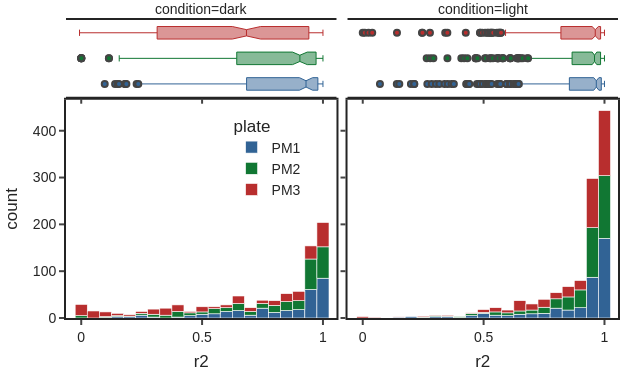

In [10]:
plot_df = fits_df.filter(pl.col("model")=="gompertz").sort("condition").fill_null(np.nan)
# Growth rates
fig1 = px.histogram(
    plot_df,
    x="mu",
    facet_col="condition",
    color="plate",
    marginal="box"
)
fig1.update_layout({
    "height": 100 * (600 / 158.75),
    "width": 180 * (600 / 158.75),
    "legend": {"x": 0.3, "y":0.7}
})
# R^2 rates
fig2 = px.histogram(
    plot_df,
    x="r2",
    facet_col="condition",
    color="plate",
    marginal="box"
)
fig2.update_layout({
    "height": 100 * (600 / 158.75),
    "width": 180 * (600 / 158.75),
    "legend": {"x": 0.3, "y": 0.7}
})

fig1.show()
fig2.show()

fig1.write_html("figures/2_mu_histogram_gompertz.html")
fig1.write_image("figures/2_mu_histogram_gompertz.png")
fig1.write_image("figures/2_mu_histogram_gompertz.svg")

fig2.write_html("figures/2_r2_histogram_gompertz.html")
fig2.write_image("figures/2_r2_histogram_gompertz.png")
fig2.write_image("figures/2_r2_histogram_gompertz.svg")